# SHAP - Random Forest (Violência contra a Mulher)

Este notebook serve para **inspecionar explicabilidade com SHAP** no modelo Random Forest do projeto.

## O que ele faz
1. Carrega o dataset processado
2. Prepara `X` e `y`
3. Treina um Random Forest com os melhores hiperparâmetros
4. Calcula métricas básicas
5. Gera explicações SHAP:
   - beeswarm / summary plot
   - bar plot de importância global
   - waterfall plot para um caso individual

> Ajuste apenas os caminhos e, se necessário, o nome da coluna alvo.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Se necessário:
# !pip install shap

import shap
print("Versão do shap:", shap.__version__)

Versão do shap: 0.51.0


## Configuração

Ajuste os caminhos abaixo se necessário.


In [3]:
BASE_PATH = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = BASE_PATH / "data" / "processed" / "df_preprocessed.parquet"
TARGET_COLUMN = "OUT_VEZES"

BEST_PARAMS = {
    "n_estimators": 300,
    "max_depth": 15,
    "min_samples_split": 2,
    "min_samples_leaf": 4,
    "max_features": "log2",
    "random_state": 42,
    "n_jobs": -1,
}

TEST_SIZE = 0.30
RANDOM_STATE = 42

print("Base path:", BASE_PATH)
print("Data path:", DATA_PATH)
print("Arquivo existe?", DATA_PATH.exists())

Base path: /Users/matias/Projetos/fiap/tech-challenge-2
Data path: /Users/matias/Projetos/fiap/tech-challenge-2/data/processed/df_preprocessed.parquet
Arquivo existe? True


## Carregar dados

Este bloco também converte colunas categóricas para códigos numéricos, caso ainda existam strings.


In [5]:
df = pd.read_parquet(DATA_PATH)

print("Shape do dataset:", df.shape)
display(df.head())

y = df[TARGET_COLUMN].astype(int)
X = df.drop(columns=[TARGET_COLUMN]).copy()

# Converte colunas categóricas / object para códigos numéricos
for col in X.select_dtypes(include=["object", "string", "category"]).columns:
    X[col] = X[col].astype("category").cat.codes

print("\nFeatures preparadas:", X.shape)
print("Target:", y.value_counts(normalize=False).to_dict())
print("\nTipos restantes:")
display(X.dtypes.value_counts())

Shape do dataset: (57022, 38)


,AG_AMEACA,AG_CORTE,AG_ENFOR,AG_ENVEN,AG_FOGO,AG_FORCA,AG_OBJETO,AG_OUTROS,AG_QUENTE,AUTOR_ALCO,...,VIOL_TRAF,DIA_SEMANA_OCOR,MES_OCOR,REL_PARCEIRO_INTIMO,REL_FAMILIAR,REL_CONHECIDO,REL_INSTITUCIONAL,REL_OUTROS_FLAG,ESCOLARIDADE,CIRC_LESAO_FAMILIA
6,1,0,0,0,0,1,0,0,0,1,...,0,SEG,JUN,1,0,0,0,0,ENSINO_MEDIO_INCOMPLETO,Y04
12,0,0,0,0,0,1,0,0,0,1,...,0,SEX,MAI,0,0,1,0,0,ENSINO_MEDIO_INCOMPLETO,Y05
30,0,0,0,0,0,1,0,0,0,1,...,0,SAB,JUN,1,0,0,0,0,FUNDAMENTAL_INCOMPLETO,Y04
39,0,0,0,0,0,1,1,0,0,1,...,0,DOM,JUN,1,0,0,0,0,ENSINO_MEDIO_COMPLETO,Y04
40,0,0,0,0,0,1,0,0,0,1,...,0,SEG,JUN,0,0,1,0,0,ENSINO_MEDIO_INCOMPLETO,Y04



Features preparadas: (57022, 37)
Target: {1: 30277, 0: 26745}

Tipos restantes:


int64    21
int8     15
int16     1
Name: count, dtype: int64

## Divisão treino / teste e treino do modelo


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

model = RandomForestClassifier(**BEST_PARAMS)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
}

pd.Series(metrics).round(4)

accuracy     0.7185
precision    0.6991
recall       0.8247
f1           0.7567
roc_auc      0.7833
dtype: float64

## Amostra para SHAP

SHAP pode ficar pesado com muitos registros.  
Por isso usamos:
- um subconjunto de background para o explicador
- um subconjunto do teste para visualização global


In [7]:
BACKGROUND_SIZE = 500
EXPLAIN_SIZE = 1000

background = X_train.sample(min(BACKGROUND_SIZE, len(X_train)), random_state=RANDOM_STATE)
X_explain = X_test.sample(min(EXPLAIN_SIZE, len(X_test)), random_state=RANDOM_STATE)

print("Background:", background.shape)
print("Amostra para explicação:", X_explain.shape)

Background: (500, 37)
Amostra para explicação: (1000, 37)


## Explicador SHAP

Para Random Forest, `TreeExplainer` costuma funcionar bem.


In [8]:
explainer = shap.TreeExplainer(model)

# Em classificadores binários, dependendo da versão do SHAP, o retorno pode variar:
# - lista com 2 arrays (classe 0 e classe 1)
# - array 3D
# - Explanation object
raw_shap = explainer.shap_values(X_explain)

def get_positive_class_shap(raw_values):
    if isinstance(raw_values, list):
        # caso clássico: [classe_0, classe_1]
        return raw_values[1]
    raw_values = np.array(raw_values)
    if raw_values.ndim == 3:
        # formato: (n_amostras, n_features, n_classes) ou semelhante
        # tentamos pegar a classe positiva na última dimensão
        return raw_values[:, :, 1]
    return raw_values

shap_values_pos = get_positive_class_shap(raw_shap)

print("Shape SHAP (classe positiva):", np.array(shap_values_pos).shape)

Shape SHAP (classe positiva): (1000, 37)


## 1) Summary plot / beeswarm

Mostra:
- quais variáveis mais influenciam o modelo
- se valores altos/baixos empurram a predição para cima ou para baixo


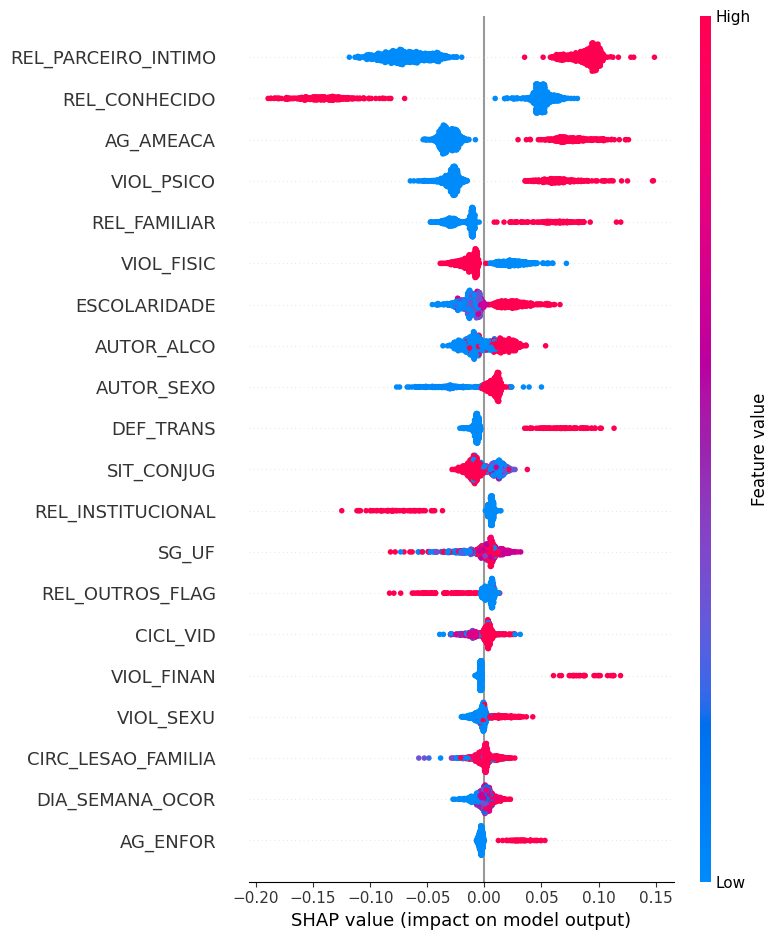

In [9]:
shap.summary_plot(shap_values_pos, X_explain, show=False)
plt.tight_layout()
plt.show()

## 2) Bar plot de importância global

Útil para relatório e apresentação.


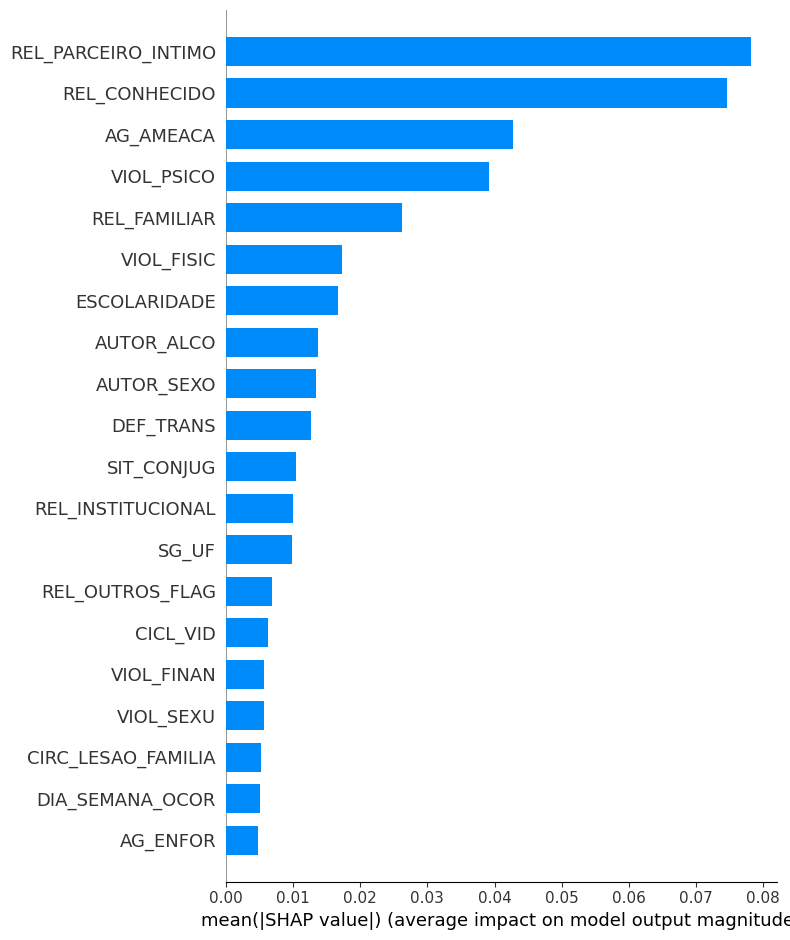

In [10]:
shap.summary_plot(shap_values_pos, X_explain, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

## 3) Importância global em tabela

Bom para salvar no relatório técnico.


In [11]:
importance_df = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": np.abs(shap_values_pos).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

importance_df.head(20)

,feature,mean_abs_shap
30,REL_PARCEIRO_INTIMO,0.078120
32,REL_CONHECIDO,0.074652
0,AG_AMEACA,0.042820
24,VIOL_PSICO,0.039248
31,REL_FAMILIAR,0.026299
19,VIOL_FISIC,0.017331
35,ESCOLARIDADE,0.016655
9,AUTOR_ALCO,0.013656
10,AUTOR_SEXO,0.013399
13,DEF_TRANS,0.012734


## 4) Waterfall plot para um caso individual

Escolha um índice e veja quais variáveis empurraram o caso para maior risco.


,AG_AMEACA,AG_CORTE,AG_ENFOR,AG_ENVEN,AG_FOGO,AG_FORCA,AG_OBJETO,AG_OUTROS,AG_QUENTE,AUTOR_ALCO,...,VIOL_TRAF,DIA_SEMANA_OCOR,MES_OCOR,REL_PARCEIRO_INTIMO,REL_FAMILIAR,REL_CONHECIDO,REL_INSTITUCIONAL,REL_OUTROS_FLAG,ESCOLARIDADE,CIRC_LESAO_FAMILIA
138159,0,0,0,0,0,1,0,0,0,0,...,0,2,3,0,0,1,0,0,0,329


,AG_AMEACA,AG_CORTE,AG_ENFOR,AG_ENVEN,AG_FOGO,AG_FORCA,AG_OBJETO,AG_OUTROS,AG_QUENTE,AUTOR_ALCO,...,VIOL_TRAF,DIA_SEMANA_OCOR,MES_OCOR,REL_PARCEIRO_INTIMO,REL_FAMILIAR,REL_CONHECIDO,REL_INSTITUCIONAL,REL_OUTROS_FLAG,ESCOLARIDADE,CIRC_LESAO_FAMILIA
138159,0,0,0,0,0,1,0,0,0,0,...,0,2,3,0,0,1,0,0,0,329


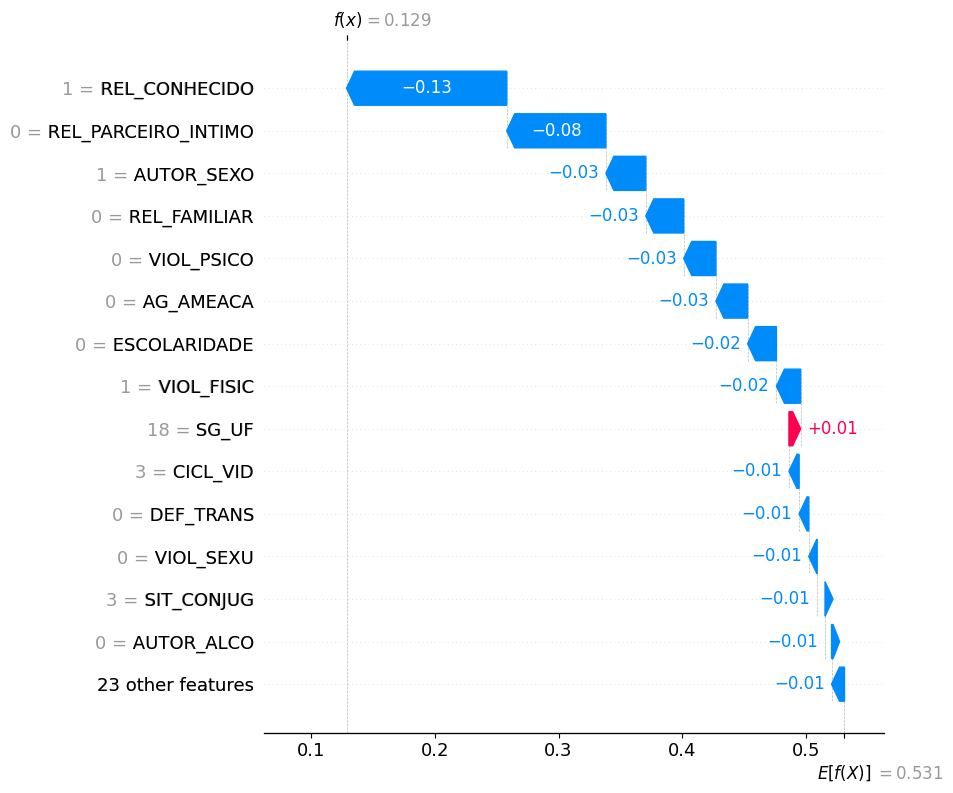

In [12]:
CASE_INDEX = 0

# Explicação individual de forma robusta
single_row = X_explain.iloc[[CASE_INDEX]]

# Preferimos usar o novo API quando possível
try:
    shap_exp = shap.Explainer(model, background)(single_row)
    display(single_row)
    shap.plots.waterfall(shap_exp[0], max_display=15)
except Exception:
    # fallback para versões antigas
    raw_single = explainer.shap_values(single_row)
    single_values = get_positive_class_shap(raw_single)[0]
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[1]

    display(single_row)
    shap.waterfall_plot(
        shap.Explanation(
            values=single_values,
            base_values=expected_value,
            data=single_row.iloc[0].values,
            feature_names=single_row.columns.tolist(),
        ),
        max_display=15
    )

## 5) Dependence plot (opcional)

Troque o nome da feature abaixo por uma das mais importantes.


Feature escolhida: VIOL_PSICO


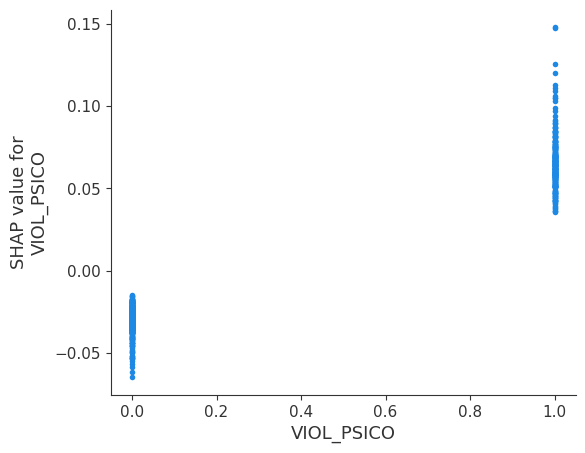

In [17]:
TOP_FEATURE = "VIOL_PSICO"
print("Feature escolhida:", TOP_FEATURE)

try:
    shap.dependence_plot(TOP_FEATURE, shap_values_pos, X_explain, interaction_index=None)
    plt.show()
except Exception as e:
    print("Não foi possível gerar dependence plot para essa versão/feature:", e)

## Leituras práticas para o relatório

Você pode usar este notebook para responder perguntas como:

- Quais variáveis mais influenciam a predição de recorrência?
- A relação com o agressor aparece entre os principais fatores?
- Violência psicológica, ameaça e situação conjugal estão entre as features de maior impacto?
- Quais fatores elevaram o risco em um caso individual?

### Sugestão de narrativa
> A análise com SHAP permitiu interpretar o modelo Random Forest em dois níveis: global e local.  
> No nível global, foram identificadas as variáveis com maior contribuição média para a predição de recorrência.  
> No nível local, foi possível explicar casos individuais, mostrando quais características elevaram ou reduziram o risco previsto pelo modelo.
